In [3]:
import sys

# Install all required packages in one cell
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn shap

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc

import shap

print("✅ All packages installed and imported successfully!")

  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 2.2 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.9 MB 2.6 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.9 MB 2.7 MB/s eta 0:00:03
   ----------- ---------------------------- 2.9/9.9 MB 2.7 MB/s eta 0:00:03
   ------------- -------------------------- 3.4/9.9 MB 2.8 MB/s eta 0:00:03
   ---------------- ----------------------- 4.2/9.9 MB 2.9 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.9 MB 2.7 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.9 MB 2.7 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.9 MB 2.8 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.9 MB 2.8 MB/s eta 0:00:02
   ---------------------------- --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.0.232 requires numpy<2,>=1, but you have numpy 2.4.6 which is incompatible.
langchain-community 0.4.1 requires dataclasses-json<0.7.0,>=0.6.7, but you have dataclasses-json 0.5.14 which is incompatible.
langchain-community 0.4.1 requires langsmith<1.0.0,>=0.1.125, but you have langsmith 0.0.5 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
Matplotlib is building the font cache; this may take a moment.
c:\Users\moid\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm

✅ All packages installed and imported successfully!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc

import shap
import warnings
warnings.filterwarnings("ignore")


In [5]:

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv(r"E:\it\Data_Science_&_Analytics\phase 2\1st TAsk\bank+marketing\bank\bank-full.csv", sep=';')

print("="*50)
print("DATASET SHAPE")
print(df.shape)

print("\nFIRST 5 ROWS")
print(df.head())

print("\nMISSING VALUES")
print(df.isnull().sum())


DATASET SHAPE
(45211, 17)

FIRST 5 ROWS
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

MISSING VALUES
age          0
job          0
marital      0
education 

In [6]:

# =========================
# ENCODE CATEGORICAL COLUMNS
# =========================

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [7]:

# =========================
# FEATURES & TARGET
# =========================

X = df.drop("y", axis=1)
y = df["y"]


In [8]:

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [9]:

# =========================
# LOGISTIC REGRESSION
# =========================

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]


In [10]:

# =========================
# RANDOM FOREST
# =========================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]



LOGISTIC REGRESSION RESULTS
F1 Score: 0.3342

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.59      0.23      0.33      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.61      0.64      9043
weighted avg       0.87      0.89      0.87      9043



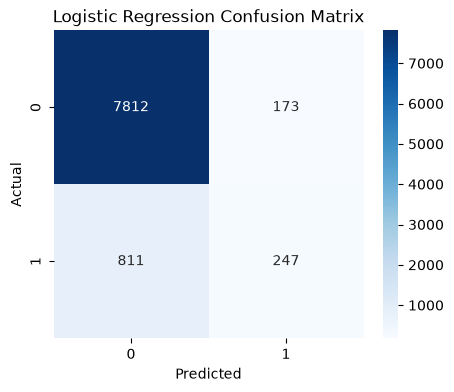

In [12]:

# =========================
# LOGISTIC REGRESSION RESULTS
# =========================

print("\n" + "="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)

f1_lr = f1_score(y_test, y_pred_lr)

print("F1 Score:", round(f1_lr,4))
print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


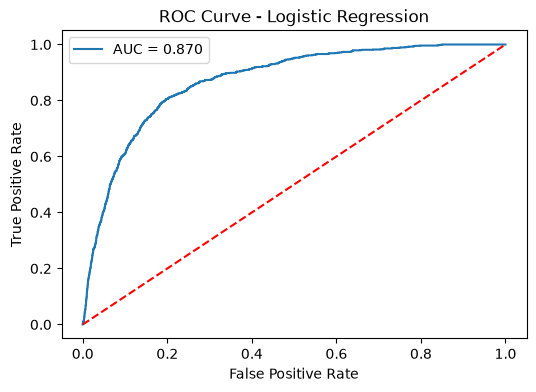

In [13]:

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6,4))
plt.plot(fpr_lr, tpr_lr, label=f'AUC = {auc_lr:.3f}')
plt.plot([0,1],[0,1],'r--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()



RANDOM FOREST RESULTS
F1 Score: 0.5006

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.65      0.41      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.72      9043
weighted avg       0.89      0.91      0.90      9043



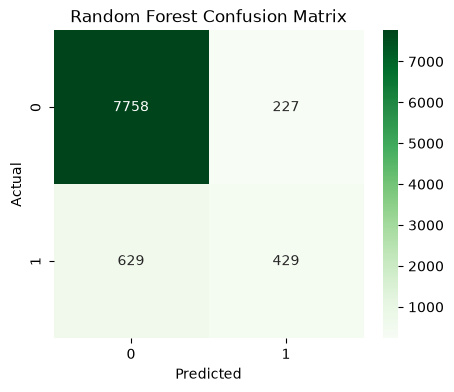

In [14]:

# =========================
# RANDOM FOREST RESULTS
# =========================

print("\n" + "="*50)
print("RANDOM FOREST RESULTS")
print("="*50)

f1_rf = f1_score(y_test, y_pred_rf)

print("F1 Score:", round(f1_rf,4))
print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


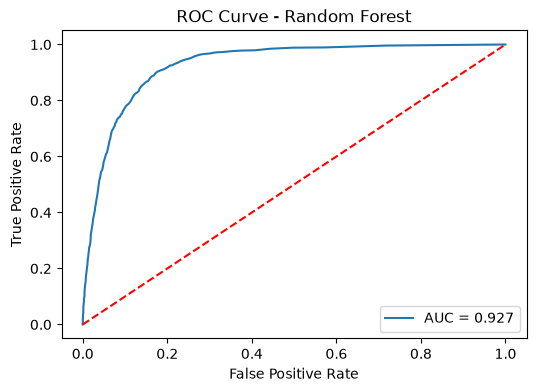

In [15]:

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f'AUC = {auc_rf:.3f}')
plt.plot([0,1],[0,1],'r--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [16]:

# =========================
# MODEL COMPARISON
# =========================

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

print("Logistic Regression F1 Score :", round(f1_lr,4))
print("Random Forest F1 Score       :", round(f1_rf,4))

if f1_rf > f1_lr:
    print("\nBest Model: Random Forest")
else:
    print("\nBest Model: Logistic Regression")



MODEL COMPARISON
Logistic Regression F1 Score : 0.3342
Random Forest F1 Score       : 0.5006

Best Model: Random Forest


In [ ]:
# =========================
# SHAP EXPLAINABILITY
# =========================

print("\n" + "="*50)
print("SHAP EXPLAINABILITY")
print("="*50)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)


In [ ]:

# Global Feature Importance

shap.summary_plot(
    shap_values[:,:,1],
    X_test,
    show=True
)


In [ ]:

# Top 5 Prediction Explanations

for i in range(5):
    print(f"\nExplaining Prediction #{i+1}")

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[i,:,1],
            base_values=explainer.expected_value[1],
            data=X_test.iloc[i],
            feature_names=X_test.columns
        ),
        max_display=10
    )